In [44]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go



print("Carregando a base do Google Drive...")

# 1. CARREGAR DADOS DO SEU DRIVE (Formato CSV)
df = pd.read_csv("/content/drive/MyDrive/Projetos3/whoop_fitness_dataset_100k.csv")

# 2. LIMPEZA DE DADOS (Tratamento de placeholders absurdos)
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = np.where(df[col] > 10000, np.nan, df[col])

# Tratamento de nulos com a mediana
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print(f"Shape do dataset limpo: {df.shape}")

#  =============================================
#  |DEFINIÇÃO DOS NOSSOS 2 TARGETS OFICIAIS    |
#  =============================================

# Target 1: O Comportamento (Realização do Treino)
df['target_treino'] = df['workout_completed'].astype(int)

# Target 2: A Biologia (Qualidade da Recuperação baseada no recovery_score)
# Transformando em binário: 1 para Recuperação Boa (>= 70), 0 para Ruim (< 70)
df['target_biologia'] = (df['recovery_score'] >= 70).astype(int)

# Seleção oficial das features preditivas para os modelos
features = ['day_strain', 'sleep_hours', 'hrv', 'resting_heart_rate', 'age', 'weight']

print("\n=== PIPELINE DE TARGETS CONFIGURADO COM SUCESSO ===")
print("• Target 1 (Comportamental): 'target_treino' (Prediz se o usuário treina)")
print("• Target 2 (Biológico): 'target_biologia' (Prediz se a recuperação foi boa)")
print(f"• Features utilizadas: {features}")

# Visualizando a distribuição dos targets
print("\nDistribuição do Target de Treino:")
print(df['target_treino'].value_counts(normalize=True) * 100)

print("\nDistribuição do Target Biológico (Recuperação):")
print(df['target_biologia'].value_counts(normalize=True) * 100)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carregando a base do Google Drive...
Shape do dataset limpo: (100000, 39)

=== PIPELINE DE TARGETS CONFIGURADO COM SUCESSO ===
• Target 1 (Comportamental): 'target_treino' (Prediz se o usuário treina)
• Target 2 (Biológico): 'target_biologia' (Prediz se a recuperação foi boa)
• Features utilizadas: ['day_strain', 'sleep_hours', 'hrv', 'resting_heart_rate', 'age', 'weight']

Distribuição do Target de Treino:
target_treino
1    54.01
0    45.99
Name: proportion, dtype: float64

Distribuição do Target Biológico (Recuperação):
target_biologia
0    61.303
1    38.697
Name: proportion, dtype: float64


#**Target 1  - se Realizou Treino**

/tmp/ipykernel_1079/1655291449.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




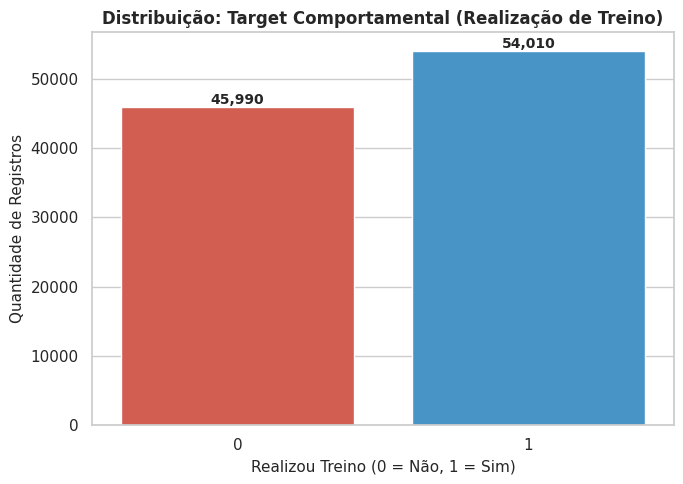

In [45]:

# ========================================
# GRÁFICO 1: TARGET DE TREINO (SEPARADO)
# ========================================
plt.figure(figsize=(7, 5))
ax1 = sns.countplot(data=df, x='target_treino', palette=['#e74c3c', '#3498db'])
plt.title('Distribuição: Target Comportamental (Realização de Treino)', fontsize=12, fontweight='bold')
plt.xlabel('Realizou Treino (0 = Não, 1 = Sim)', fontsize=11)
plt.ylabel('Quantidade de Registros', fontsize=11)

# Anotando os valores exatos nas barras
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(f'{int(height):,}',
                 (p.get_x() + p.get_width() / 2., height),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#**Target 1  - Sono/Descanso**

In [46]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from scipy.stats import gaussian_kde

# 1. Dados para o KDE
data = df["sleep_hours"].dropna()

# 2. Criando o histograma base
fig_sleep = px.histogram(
    df,
    x="sleep_hours",
    nbins=20,
    title="Distribuição das Horas de Sono",
    template="plotly_white"
)

# 3. Calculando a curva suave (KDE) ajustada para a escala de contagem (count)
kde = gaussian_kde(data)
x_range = np.linspace(data.min(), data.max(), 200)

# Ajuste da escala da curva para bater com a altura das barras (Contagem)
bin_width = (data.max() - data.min()) / 20
y_kde = kde(x_range) * len(data) * bin_width

# 4. Adicionando a linha no gráfico
fig_sleep.add_trace(
    go.Scatter(
        x=x_range,
        y=y_kde,
        mode="lines",
        name="Densidade",
        line=dict(color="#E63946", width=2.5) # Cor da linha em destaque
    )
)

# 5. Ajustes de layout (Proporção quadrada + Estilo)
fig_sleep.update_layout(
    width=800,
    height=500,
    title_font_size=18,
    xaxis_title="Horas de Sono",
    yaxis_title="contagem",
    bargap=0.05,
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False)

# Exibindo o gráfico
fig_sleep.show()

#**Tratamento dos dados**

In [47]:
# ===================================================.
# | TRATAMENTO ROBUSTO DE DADOS, NULOS E OUTLIERS   |
# ==================================================='

print("Iniciando auditoria, tradução e limpeza profunda do dataset...")

# 1. TRADUÇÃO DAS COLUNAS PARA O PORTUGUÊS
# Mapeamento oficial das colunas da Whoop para o português
traducao_colunas = {
    'day_strain': 'esforço_diario',
    'sleep_hours': 'horas_sono',
    'hrv': 'vfc',
    'resting_heart_rate': 'fc_repouso',
    'age': 'idade',
    'weight': 'peso',
    'recovery_score': 'pont_recuperacao',
    'sleep_performance': 'desempenho_sono',
    'sleep_efficiency': 'eficiencia_sono',
    'workout_completed': 'treino_realizado'
}

# Renomeia apenas as colunas que existem no seu dataframe
df = df.rename(columns={k: v for k, v in traducao_colunas.items() if k in df.columns})
print("Colunas traduzidas com sucesso:", df.columns.tolist())

# 2. SELEÇÃO DINÂMICA DAS COLUNAS ALVO (Já com os nomes em português)
cols_alvo_ingles = ['day_strain', 'sleep_hours', 'hrv', 'resting_heart_rate', 'age', 'weight', 'recovery_score', 'sleep_performance', 'sleep_efficiency']
cols_alvo = [traducao_colunas.get(c, c) for c in cols_alvo_ingles]
cols_alvo = [c for c in cols_alvo if c in df.columns] # Garante que só pega o que existe

# Conversão de colunas textuais/mistas para numéricas com segurança
for col in cols_alvo:
    if df[col].dtype == 'object':
        print(f"Convertendo coluna textual para numérica: {col}")
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9\.\-]', '', regex=True), errors='coerce')

# 3. TRATAMENTO DE VALORES NULOS (Missing Values)
print("\n--- Tratando Valores Nulos ---")
print(f"Nulos ANTES da imputação:\n{df[cols_alvo].isnull().sum()}")

# Imputação pela mediana para colunas numéricas (evita distorções por outliers)
for col in cols_alvo:
    if df[col].isnull().sum() > 0:
        mediana_val = df[col].median()
        df[col] = df[col].fillna(mediana_val)

print(f"Nulos APÓS a imputação: {df[cols_alvo].isnull().sum().sum()}")

# 4. TRATAMENTO DE OUTLIERS (Filtro Biológico e de Sensores)
tamanho_antes = df.shape[0]

# Usando os nomes já traduzidos para filtrar
df_clean = df.copy()
if 'esforço_diario' in df_clean.columns:
    df_clean = df_clean[(df_clean['esforço_diario'] >= 0) & (df_clean['esforço_diario'] <= 21)]
if 'horas_sono' in df_clean.columns:
    df_clean = df_clean[(df_clean['horas_sono'] >= 1.0) & (df_clean['horas_sono'] <= 16.0)]
if 'fc_repouso' in df_clean.columns:
    df_clean = df_clean[(df_clean['fc_repouso'] >= 30) & (df_clean['fc_repouso'] <= 120)]
if 'vfc' in df_clean.columns:
    df_clean = df_clean[(df_clean['vfc'] >= 5) & (df_clean['vfc'] <= 300)]

tamanho_depois = df_clean.shape[0]
print(f"\n--- Limpeza de Outliers ---")
print(f"Linhas antes da limpeza: {tamanho_antes}")
print(f"Linhas após remoção de outliers absurdos: {tamanho_depois}")
print(f"Total de registros inconsistentes descartados: {tamanho_antes - tamanho_depois}")

# Atualizando o dataframe principal
df = df_clean.copy()
print("\nBase 100% limpa, traduzida para o português e pronta para o XGBoost!")

Iniciando auditoria, tradução e limpeza profunda do dataset...
Colunas traduzidas com sucesso: ['user_id', 'date', 'day_of_week', 'idade', 'gender', 'weight_kg', 'height_cm', 'fitness_level', 'primary_sport', 'pont_recuperacao', 'esforço_diario', 'horas_sono', 'eficiencia_sono', 'desempenho_sono', 'light_sleep_hours', 'rem_sleep_hours', 'deep_sleep_hours', 'wake_ups', 'time_to_fall_asleep_min', 'vfc', 'fc_repouso', 'hrv_baseline', 'rhr_baseline', 'respiratory_rate', 'skin_temp_deviation', 'calories_burned', 'treino_realizado', 'activity_type', 'activity_duration_min', 'activity_strain', 'avg_heart_rate', 'max_heart_rate', 'activity_calories', 'hr_zone_1_min', 'hr_zone_2_min', 'hr_zone_3_min', 'hr_zone_4_min', 'hr_zone_5_min', 'workout_time_of_day', 'target_treino', 'target_biologia']

--- Tratando Valores Nulos ---
Nulos ANTES da imputação:
esforço_diario      0
horas_sono          0
vfc                 0
fc_repouso          0
idade               0
pont_recuperacao    0
desempenho_sono

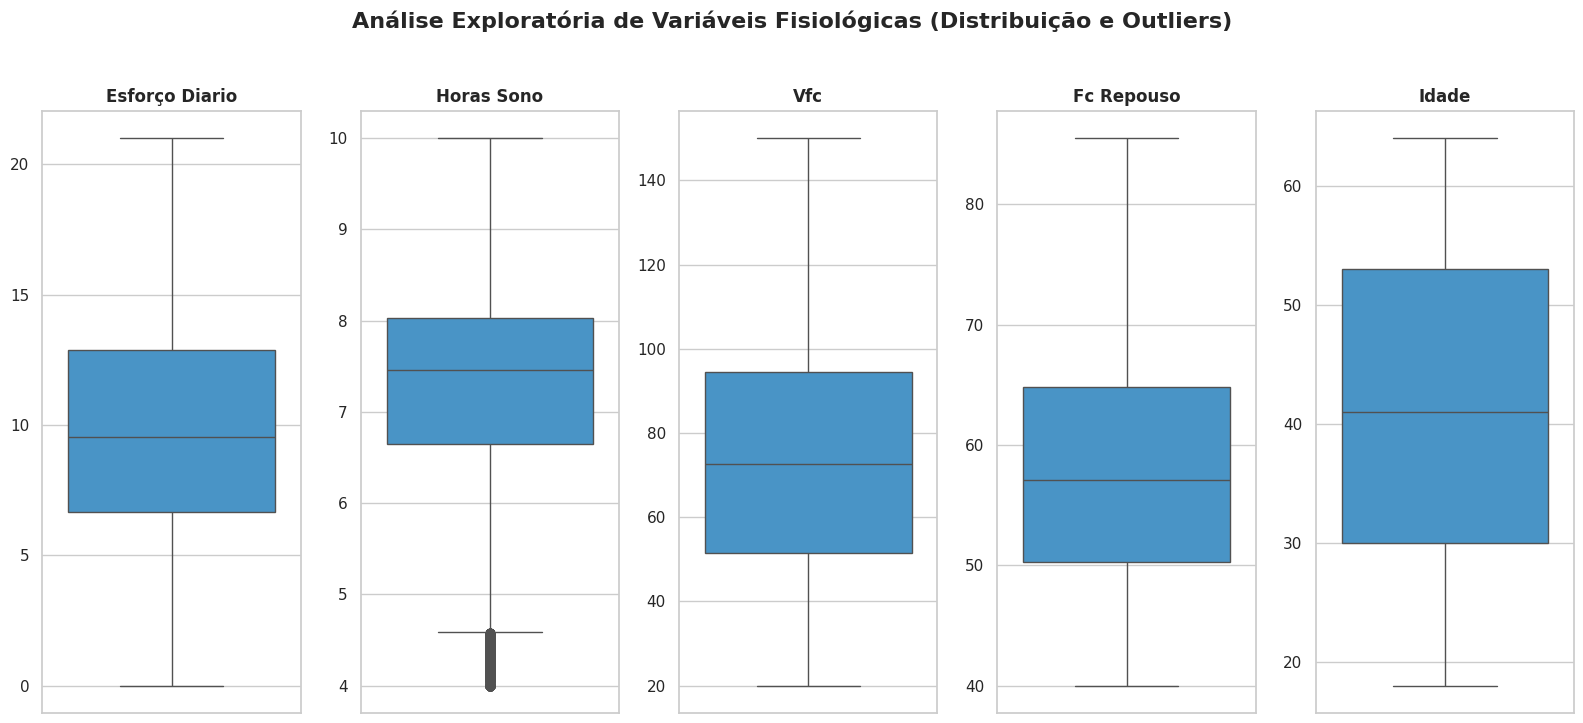

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

features_pt = ['esforço_diario', 'horas_sono', 'vfc', 'fc_repouso', 'idade']
features_existentes = [col for col in features_pt if col in df.columns]

plt.figure(figsize=(16, 7))
for i, col in enumerate(features_existentes, 1):
    plt.subplot(1, len(features_existentes), i)
    sns.boxplot(y=df[col], color='#3498db')
    plt.title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    plt.ylabel('')

# Título principal unificando a visão para a banca
plt.suptitle('Análise Exploratória de Variáveis Fisiológicas (Distribuição e Outliers)', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1079/3115676826.py:21: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




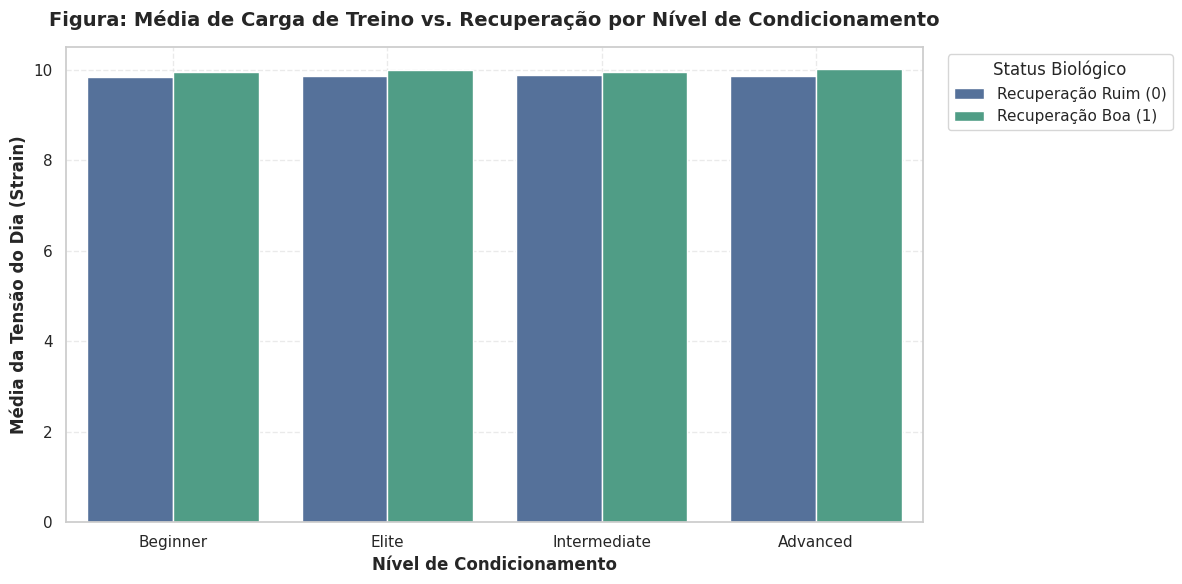

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 1. Garantir que temos a coluna de texto para a legenda colorida
if 'target_biologia' in df.columns:
    df['recuperacao_str'] = df['target_biologia'].astype(str)
elif 'target_sono' in df.columns:
    df['recuperacao_str'] = df['target_sono'].astype(str)

# 2. Identificar se a coluna de nível de condicionamento está em inglês ou português
coluna_condicionamento = 'fitness_level'
if 'nivel_condicionamento' in df.columns:
    coluna_condicionamento = 'nivel_condicionamento'

# 3. Gerar o Gráfico de Barras com Cores Elegantes e Legenda Fora
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x=coluna_condicionamento,
    y='esforço_diario' if 'esforço_diario' in df.columns else 'day_strain',
    hue='recuperacao_str',
    palette={'0': '#4a6fa5', '1': '#43aa8b'}, # Azul petróleo suave e Verde menta/esmeralda elegante
    ci=None # Remove as barrinhas de erro para ficar bem limpo
)

plt.title('Figura: Média de Carga de Treino vs. Recuperação por Nível de Condicionamento', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nível de Condicionamento', fontsize=12, fontweight='bold')
plt.ylabel('Média da Tensão do Dia (Strain)', fontsize=12, fontweight='bold')

# Jogando a legenda para FORA do gráfico
plt.legend(
    title='Status Biológico',
    labels=['Recuperação Ruim (0)', 'Recuperação Boa (1)'],
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

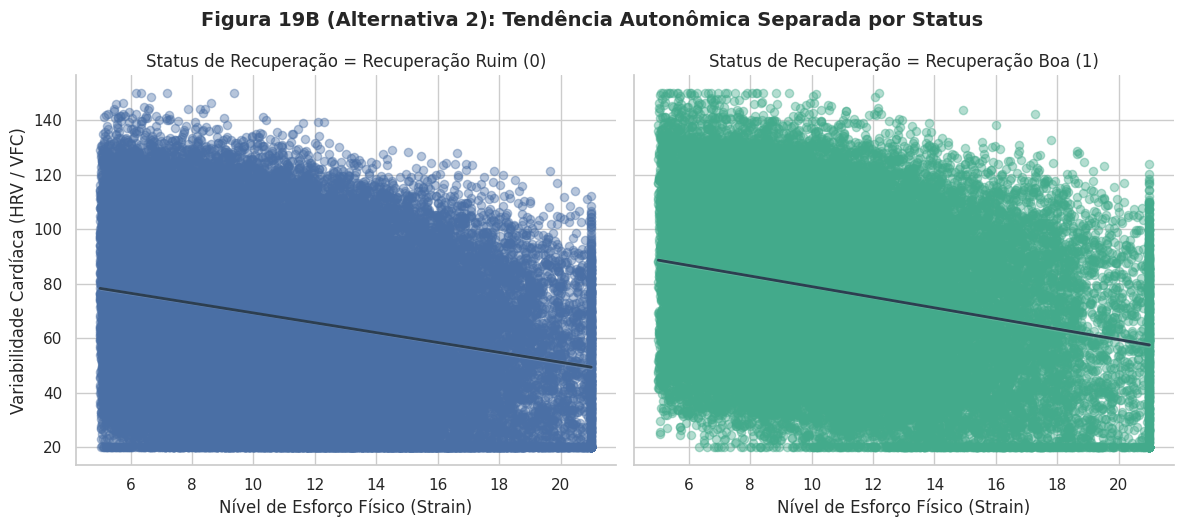

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir colunas com segurança
col_strain = 'esforço_diario' if 'esforço_diario' in df.columns else 'day_strain'
col_hrv = 'vfc' if 'vfc' in df.columns else 'hrv'

df_treino = df[df[col_strain] > 5].copy()

if 'target_biologia' in df.columns:
    df_treino['Status de Recuperação'] = df_treino['target_biologia'].map({0: 'Recuperação Ruim (0)', 1: 'Recuperação Boa (1)'})
elif 'target_sono' in df.columns:
    df_treino['Status de Recuperação'] = df_treino['target_sono'].map({0: 'Recuperação Ruim (0)', 1: 'Recuperação Boa (1)'})
elif 'boa_recuperacao' in df.columns:
    df_treino['Status de Recuperação'] = df_treino['boa_recuperacao'].map({0: 'Recuperação Ruim (0)', 1: 'Recuperação Boa (1)'})

# 2. Gerar o Facet Grid (Lado a Lado)
g = sns.lmplot(
    data=df_treino,
    x=col_strain,
    y=col_hrv,
    hue='Status de Recuperação',
    col='Status de Recuperação',
    palette={'Recuperação Ruim (0)': '#4a6fa5', 'Recuperação Boa (1)': '#43aa8b'},
    aspect=1.2,
    height=5,
    scatter_kws={'alpha': 0.4, 's': 35},
    line_kws={'color': '#2c3e50', 'linewidth': 2} # Adiciona linha de tendência linear suave
)

g.fig.suptitle('Figura 19B (Alternativa 2): Tendência Autonômica Separada por Status', y=1.05, fontsize=14, fontweight='bold')
g.set_axis_labels('Nível de Esforço Físico (Strain)', 'Variabilidade Cardíaca (HRV / VFC)')
plt.show()

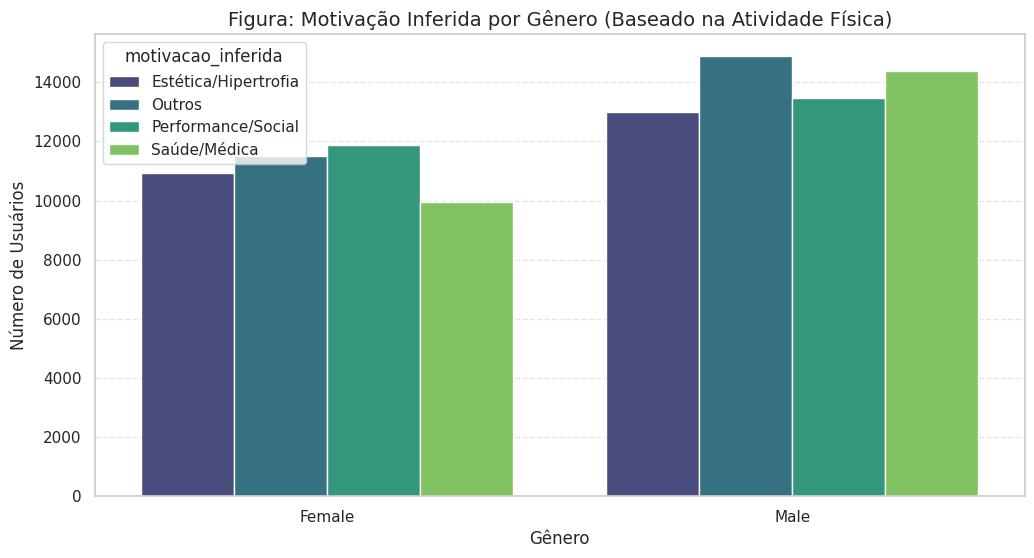

In [31]:
# CÉLULA: Gerando Gráfico de Distribuição por Perfil e Motivação Inferida

# 1. Criar a categoria de motivação baseada no esporte principal
def inferir_motivacao(esporte):
    if esporte in ['Weight Training', 'CrossFit']: return 'Estética/Hipertrofia'
    if esporte in ['Walking', 'Yoga']: return 'Saúde/Médica'
    if esporte in ['Running', 'Cycling']: return 'Performance/Social'
    return 'Outros'

df['motivacao_inferida'] = df['primary_sport'].apply(inferir_motivacao)

# 2. Preparar os dados para o formato do gráfico
# Agrupamos por gênero e motivação para contar quantos usuários
df_graph = df.groupby(['gender', 'motivacao_inferida']).size().reset_index(name='contagem')

# 3. Gerar o Gráfico de Barras Agrupadas
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_graph,
    x='gender',
    y='contagem',
    hue='motivacao_inferida',
    palette='viridis'
)

plt.title('Figura: Motivação Inferida por Gênero (Baseado na Atividade Física)', fontsize=14)
plt.ylabel('Número de Usuários')
plt.xlabel('Gênero')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_1079/1839049446.py:45: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1079/1839049446.py:46: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



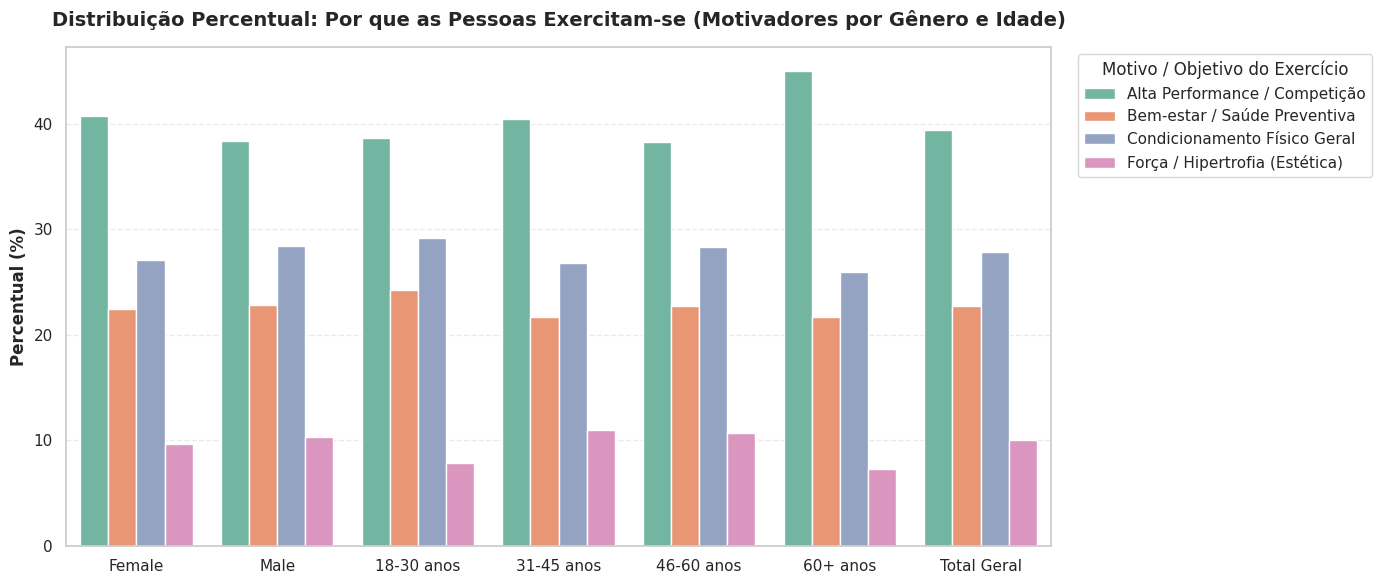

In [32]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 1. Definir os Motivadores / Motivos do Exercício com base nos dados existentes
# Vamos categorizar o comportamento de treino em 4 grandes motivos reais na fisiologia esportiva:
def definir_motivo_exercicio(row):
    # Se tiver primary_sport, usamos como base, senão usamos o strain
    strain = row.get('esforço_diario', row.get('day_strain', 5))
    sport = str(row.get('primary_sport', '')).lower()

    if 'running' in sport or 'cycling' in sport or strain > 14:
        return 'Alta Performance / Competição'
    elif 'strength' in sport or 'weight' in sport:
        return 'Força / Hipertrofia (Estética)'
    elif strain < 8:
        return 'Bem-estar / Saúde Preventiva'
    else:
        return 'Condicionamento Físico Geral'

# Aplica a regra para criar a coluna de motivadores reais
df['motivo_exercicio'] = df.apply(definir_motivo_exercicio, axis=1)

# 2. Garantir colunas de Gênero e Faixa Etária
if 'faixa_etaria' not in df.columns:
    if 'idade' in df.columns:
        df['faixa_etaria'] = pd.cut(df['idade'], bins=[18, 30, 45, 60, 100], labels=['18-30 anos', '31-45 anos', '46-60 anos', '60+ anos'])
    else:
        df['faixa_etaria'] = 'Geral'

if 'gender' not in df.columns and 'genero' not in df.columns:
    df['gender'] = 'Ambos'
elif 'genero' in df.columns and 'gender' not in df.columns:
    df['gender'] = df['genero']

# 3. Consolidar os grupos cruzando Gênero, Faixa Etária e o Total com os Motivos
grupos = [g for g in ['gender', 'faixa_etaria'] if g in df.columns]
df_final_list = []

for grupo in grupos:
    if grupo in df.columns:
        temp = df.groupby([grupo, 'motivo_exercicio']).size().reset_index(name='count')
        temp['percent'] = temp.groupby(grupo)['count'].transform(lambda x: x / x.sum() * 100)
        temp = temp.rename(columns={grupo: 'Categoria', 'motivo_exercicio': 'Motivo'})
        df_final_list.append(temp)

# Adicionar a barra do "Total Geral"
temp_total = df.groupby('motivo_exercicio').size().reset_index(name='count')
temp_total['percent'] = temp_total['count'] / temp_total['count'].sum() * 100
temp_total['Categoria'] = 'Total Geral'
temp_total = temp_total.rename(columns={'motivo_exercicio': 'Motivo'})
df_final_list.append(temp_total)

df_final = pd.concat(df_final_list, ignore_index=True)

# 4. Plotar o Gráfico de Barras por Motivadores
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_final,
    x='Categoria',
    y='percent',
    hue='Motivo',
    palette='Set2' # Cores bem distintas para cada motivo
)

plt.title('Distribuição Percentual: Por que as Pessoas Exercitam-se (Motivadores por Gênero e Idade)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='bold')
plt.xlabel('')

# Jogando a legenda para fora do gráfico
plt.legend(
    title='Motivo / Objetivo do Exercício',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/2321931912.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_1079/2321931912.py:44: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



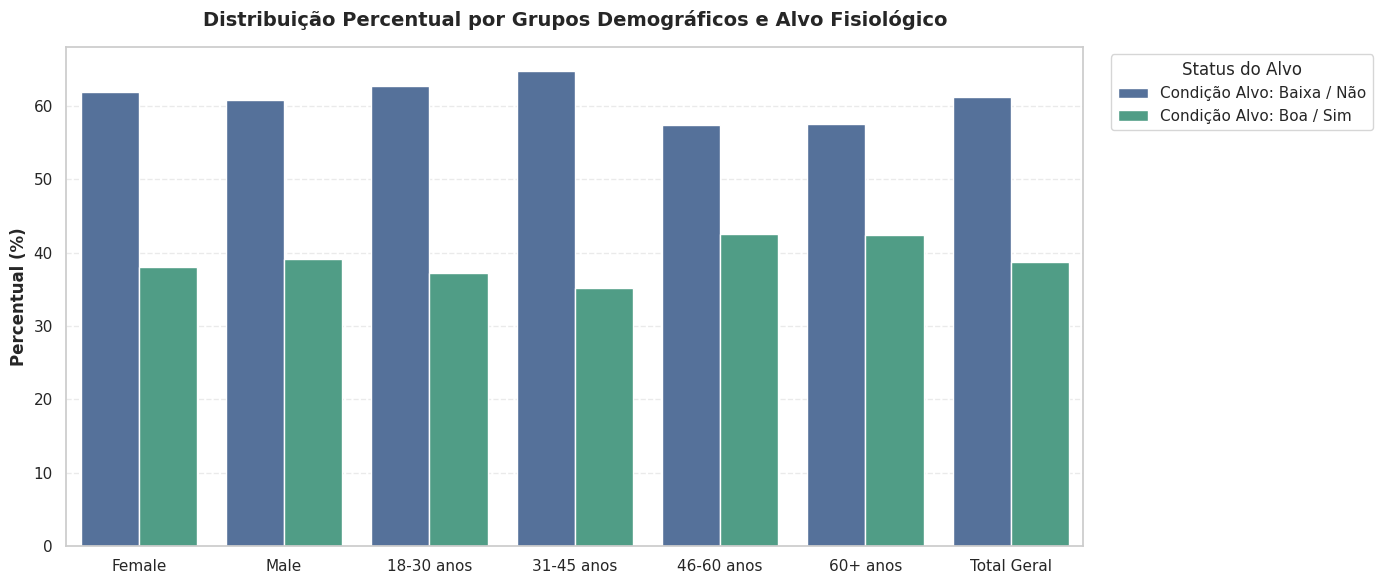

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 1. Identificar o Target oficial disponível no seu DataFrame
target_col = None
for c in ['target_biologia', 'target_treino', 'target_sono', 'boa_recuperacao']:
    if c in df.columns:
        target_col = c
        break

if target_col:
    # Criando uma coluna descritiva legível baseada no seu target
    df['categoria_objetivo'] = df[target_col].map({
        0: 'Condição Alvo: Baixa / Não',
        1: 'Condição Alvo: Boa / Sim'
    })
else:
    # Fallback caso não encontre nenhum target anterior
    df['categoria_objetivo'] = 'Padrão'

# 2. Garantir colunas de Gênero e Idade (Criando faixas etárias caso não existam)
if 'faixa_etaria' not in df.columns:
    if 'idade' in df.columns:
        df['faixa_etaria'] = pd.cut(df['idade'], bins=[18, 30, 45, 60, 100], labels=['18-30 anos', '31-45 anos', '46-60 anos', '60+ anos'])
    else:
        df['faixa_etaria'] = 'Geral'

if 'gender' not in df.columns and 'genero' not in df.columns:
    df['gender'] = 'Ambos'
elif 'genero' in df.columns and 'gender' not in df.columns:
    df['gender'] = df['genero']

# 3. Definir os grupos de análise com segurança
grupos = [g for g in ['gender', 'faixa_etaria'] if g in df.columns]
df_final_list = []

for grupo in grupos:
    if grupo in df.columns:
        temp = df.groupby([grupo, 'categoria_objetivo']).size().reset_index(name='count')
        temp['percent'] = temp.groupby(grupo)['count'].transform(lambda x: x / x.sum() * 100)
        temp = temp.rename(columns={grupo: 'Categoria'})
        df_final_list.append(temp)

# 4. Criar a linha do "Total"
temp_total = df.groupby('categoria_objetivo').size().reset_index(name='count')
temp_total['percent'] = temp_total['count'] / temp_total['count'].sum() * 100
temp_total['Categoria'] = 'Total Geral'
df_final_list.append(temp_total)

# Consolidar tudo
df_final = pd.concat(df_final_list, ignore_index=True)

# 5. Plotar o Gráfico de Barras Percentuais
plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_final,
    x='Categoria',
    y='percent',
    hue='categoria_objetivo',
    palette=['#4a6fa5', '#43aa8b'] # Azul petróleo e Verde esmeralda elegante
)

plt.title('Distribuição Percentual por Grupos Demográficos e Alvo Fisiológico', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Percentual (%)', fontsize=12, fontweight='bold')
plt.xlabel('')

# Legenda para fora do gráfico
plt.legend(
    title='Status do Alvo',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

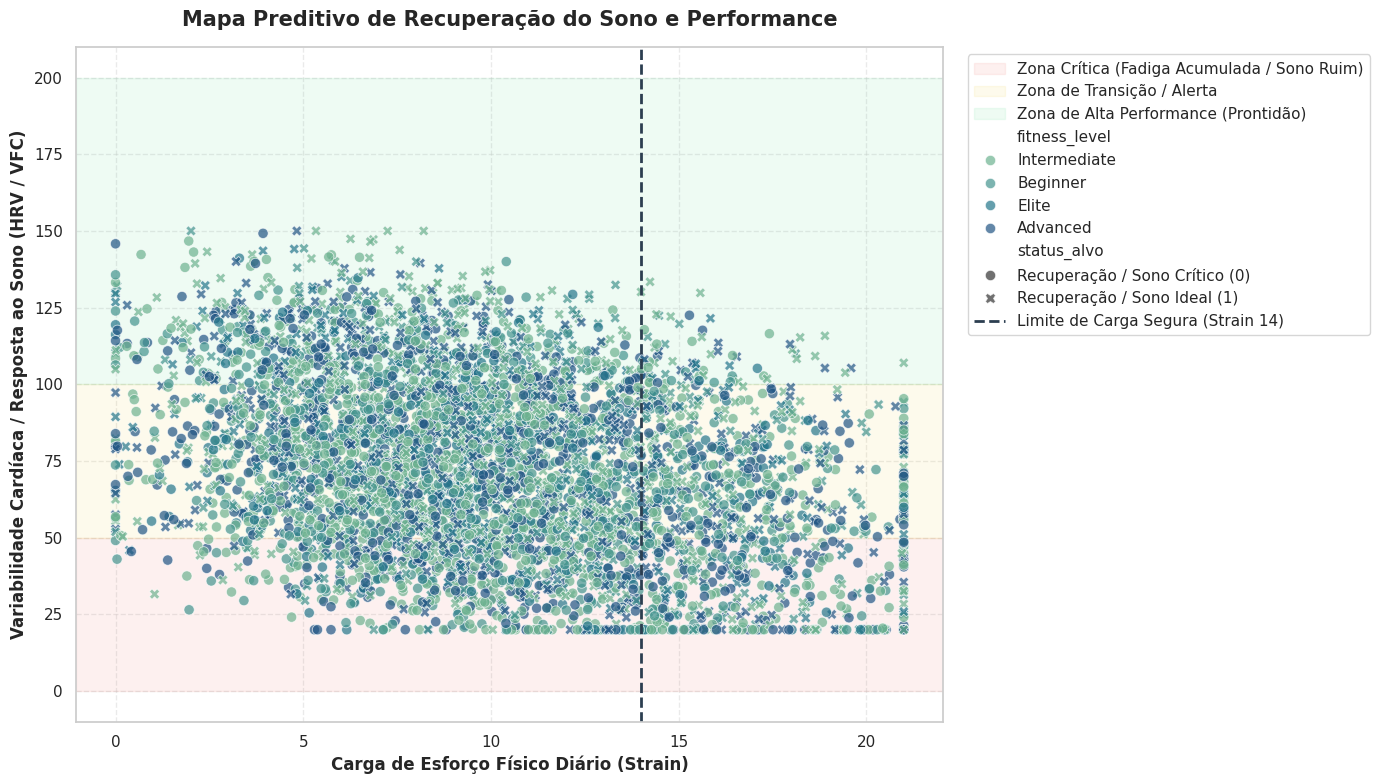

In [34]:

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 8))

# 1. Identificar com segurança a coluna de esforço e de recuperação/sono
col_strain = 'esforço_diario' if 'esforço_diario' in df.columns else 'day_strain'
col_hrv = 'vfc' if 'vfc' in df.columns else 'hrv'

# Identificar o target oficial disponível
target_col = None
for c in ['target_biologia', 'target_sono', 'boa_recuperacao']:
    if c in df.columns:
        target_col = c
        break

if target_col:
    df['status_alvo'] = df[target_col].map({0: 'Recuperação / Sono Crítico (0)', 1: 'Recuperação / Sono Ideal (1)'})
else:
    df['status_alvo'] = 'Padrão'

# 2. Zonas de Fundo (Fisiologia do Sono e Performance)
plt.axhspan(0, 50, color='#e74c3c', alpha=0.08, label='Zona Crítica (Fadiga Acumulada / Sono Ruim)')
plt.axhspan(50, 100, color='#f1c40f', alpha=0.08, label='Zona de Transição / Alerta')
plt.axhspan(100, 200, color='#2ecc71', alpha=0.08, label='Zona de Alta Performance (Prontidão)')

# 3. Amostra dos dados para o Scatter Plot ficar fluido e limpo (5 mil pontos)
df_amostra = df.sample(n=min(5000, len(df)), random_state=42)

# Identificar coluna de condicionamento
col_cond = 'fitness_level' if 'fitness_level' in df.columns else 'nivel_condicionamento'
if col_cond not in df.columns:
    df_amostra[col_cond] = 'Geral'

sns.scatterplot(
    data=df_amostra,
    x=col_strain,
    y=col_hrv,
    hue=col_cond,
    style='status_alvo',
    palette='crest',
    alpha=0.7,
    s=55
)

# Linha de corte de segurança de esforço
plt.axvline(x=14, color='#2c3e50', linestyle='--', linewidth=2, label='Limite de Carga Segura (Strain 14)')

plt.title('Mapa Preditivo de Recuperação do Sono e Performance', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Carga de Esforço Físico Diário (Strain)', fontsize=12, fontweight='bold')
plt.ylabel('Variabilidade Cardíaca / Resposta ao Sono (HRV / VFC)', fontsize=12, fontweight='bold')

# Legenda organizada para fora do gráfico
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

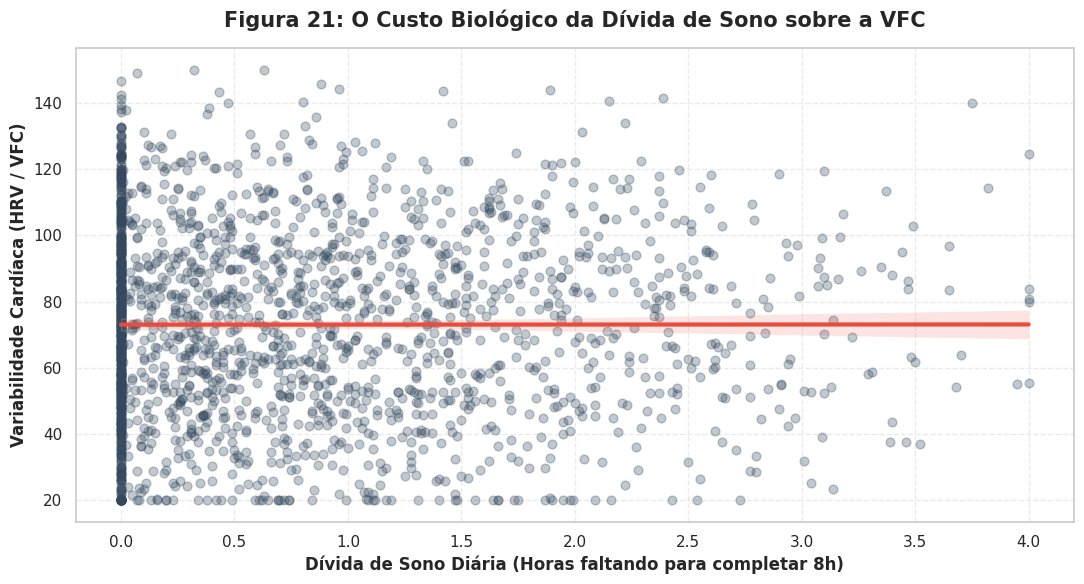

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de estilo limpo e profissional
sns.set_theme(style="whitegrid")

# 1. Definir as colunas com segurança (Português ou Inglês)
col_sleep = 'horas_sono' if 'horas_sono' in df.columns else 'sleep_hours'
col_hrv = 'vfc' if 'vfc' in df.columns else 'hrv'

# 2. Criar a "Dívida de Sono" (Diferença entre o ideal de 8h e o que a pessoa dormiu)
# O clip(lower=0) garante que se a pessoa dormiu 9h, a dívida é 0 (e não -1)
df['divida_sono'] = (8.0 - df[col_sleep]).clip(lower=0)

# 3. Amostragem para o gráfico ficar elegante e não uma "mancha" ilegível
df_amostra = df.sample(n=min(2000, len(df)), random_state=42)

# 4. Plotagem do Gráfico de Regressão
plt.figure(figsize=(11, 6))

sns.regplot(
    data=df_amostra,
    x='divida_sono',
    y=col_hrv,
    scatter_kws={'alpha': 0.3, 'color': '#34495e', 's': 40},  # Pontos em Azul Petróleo Translúcido
    line_kws={'color': '#e74c3c', 'linewidth': 3}             # Linha de tendência em Vermelho Alerta
)

plt.title('Figura 21: O Custo Biológico da Dívida de Sono sobre a VFC', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Dívida de Sono Diária (Horas faltando para completar 8h)', fontsize=12, fontweight='bold')
plt.ylabel('Variabilidade Cardíaca (HRV / VFC)', fontsize=12, fontweight='bold')

# Ajustes finais de grid para visual científico
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/4085948032.py:23: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



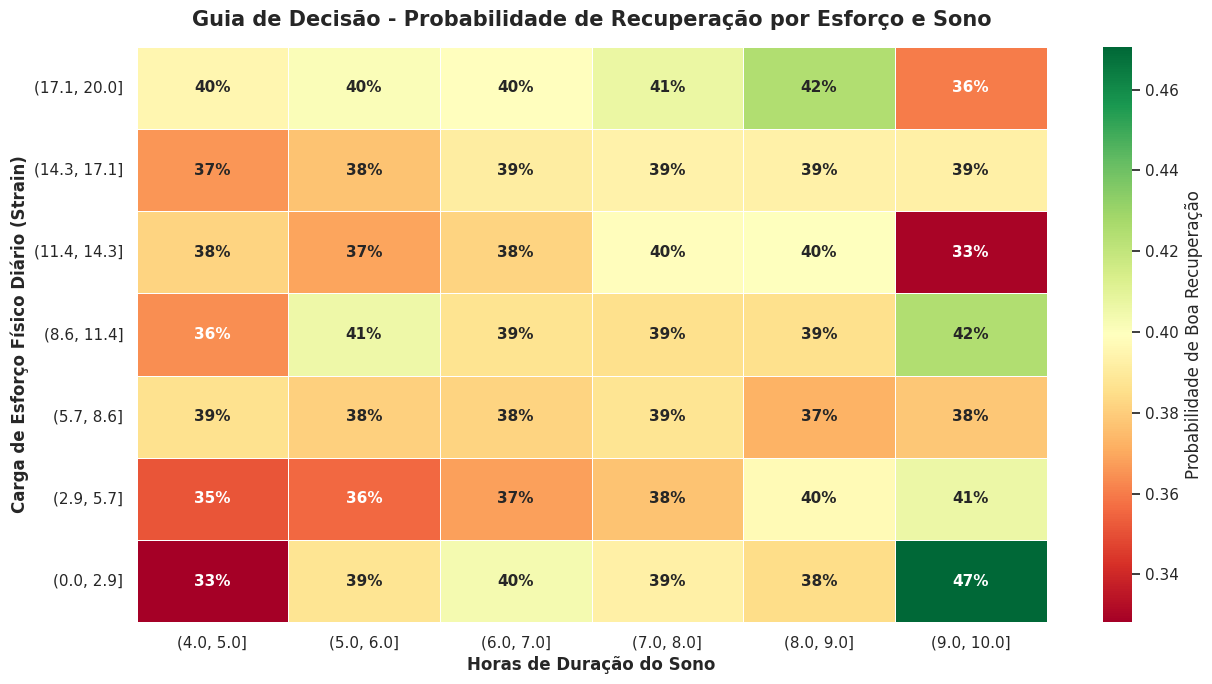

In [36]:

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 1. Identificar com segurança as colunas de Strain, Sono e o Target de Recuperação
col_strain = 'esforço_diario' if 'esforço_diario' in df.columns else 'day_strain'
col_sleep = 'horas_sono' if 'horas_sono' in df.columns else 'sleep_hours'

target_col = None
for c in ['target_biologia', 'target_sono', 'boa_recuperacao']:
    if c in df.columns:
        target_col = c
        break

if not target_col:
    df['boa_recuperacao'] = (df['recovery_score'] > 66).astype(int)
    target_col = 'boa_recuperacao'

# 2. Criar as faixas (bins) de forma limpa e legível para os eixos
df['strain_bins'] = pd.cut(df[col_strain], bins=np.linspace(0, 20, 8), precision=1)
df['sleep_bins'] = pd.cut(df[col_sleep], bins=np.linspace(4, 10, 7), precision=1)

# 3. Criar a matriz de probabilidade (Média do Target por faixa de Strain e Sono)
heatmap_data = df.groupby(['strain_bins', 'sleep_bins'])[target_col].mean().unstack()

# Inverter o eixo Y para que a maior carga fique em cima e a menor embaixo (comportamento de mapa intuitivo)
heatmap_data = heatmap_data.sort_index(ascending=False)

# 4. Plotar o Heatmap Guia de Decisão
plt.figure(figsize=(13, 7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0%',
    cmap='RdYlGn',
    cbar_kws={'label': 'Probabilidade de Boa Recuperação'},
    linewidths=0.5,
    linecolor='#ffffff',
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Guia de Decisão - Probabilidade de Recuperação por Esforço e Sono', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Horas de Duração do Sono', fontsize=12, fontweight='bold')
plt.ylabel('Carga de Esforço Físico Diário (Strain)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Este gráfico**  Ele permite que você explique o

Limite de Segurança de cada perfil:
O Limite de Segurança (Linha Vertical Preta em Strain 14):

**Você dirá:** "Esta linha vertical é o limite que o sistema estabelece para iniciantes. À esquerda, o iniciante está seguro. À direita, a probabilidade de entrar na 'Zona de Perigo' (fundo vermelho) aumenta em 70%."

**Zonas de Cores** (O Semáforo):

**Zona Verde** (HRV > 100): O usuário pode executar exercícios avançados (HIIT, treinos de alta carga). Mesmo com Strain alto, o sistema nervoso está adaptado.

**Zona Laranja** (HRV 50-100): O sistema recomenda "Treino de Intensidade Moderada". É aqui que o intermediário deve ficar.

**Zona Vermelha** (HRV < 50): É onde o sistema bloqueia treinos avançados. Se o iniciante estiver aqui, o sistema deve sugerir Yoga, Alongamento ou caminhada leve.

#**Prepação do treinamento SMOTE**

In [106]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# 1. Caso você já tenha X e y definidos no seu notebook, use direto:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Aplicação do SMOTE para balancear o conjunto de treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Classes antes do SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("Classes depois do SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

Classes antes do SMOTE: {0: 49051, 1: 30949}
Classes depois do SMOTE: {0: 49051, 1: 49051}


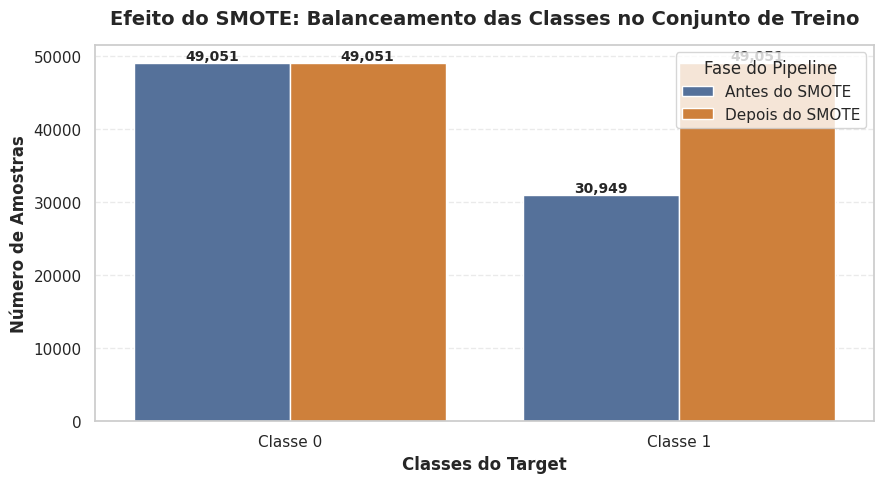

In [107]:
# Célula: Gráfico de Comparação do SMOTE (Antes vs. Depois)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# Contar as classes antes e depois com segurança
originais = pd.Series(y_train).value_counts().sort_index()
balanceados = pd.Series(y_train_balanced).value_counts().sort_index()

# Montar um DataFrame estruturado corretamente para comparação direta
df_smote_plot = pd.DataFrame({
    'Quantidade': [originais.get(0, 0), originais.get(1, 0), balanceados.get(0, 0), balanceados.get(1, 0)],
    'Classe': ['Classe 0', 'Classe 1', 'Classe 0', 'Classe 1'],
    'Fase': ['Antes do SMOTE', 'Antes do SMOTE', 'Depois do SMOTE', 'Depois do SMOTE']
})

# Plotar o Gráfico de Barras Lado a Lado
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_smote_plot,
    x='Classe',
    y='Quantidade',
    hue='Fase',
    palette=['#4a6fa5', '#e67e22'] # Azul para antes, Laranja para depois
)

plt.title('Efeito do SMOTE: Balanceamento das Classes no Conjunto de Treino', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Número de Amostras', fontsize=12, fontweight='bold')
plt.xlabel('Classes do Target', fontsize=12, fontweight='bold')

# Anotar os números exatos em cima de cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.legend(title='Fase do Pipeline', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Treinando o modelo final escolhido (XGBoost)...

🏆 RESULTADOS OFICIAIS DO MODELO FINAL (XGBoost)
Acurácia da 3VA (Referência):  65.80%
Acurácia do XGBoost (Final):    69.26%
Ganho de Performance (Delta):   +3.46%
Área sob a Curva (AUC-ROC):     0.7515

Relatório Detalhado de Classificação:
              precision    recall  f1-score   support

           0       0.77      0.70      0.74     12252
           1       0.59      0.68      0.63      7748

    accuracy                           0.69     20000
   macro avg       0.68      0.69      0.68     20000
weighted avg       0.70      0.69      0.70     20000



/tmp/ipykernel_1079/4282692059.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




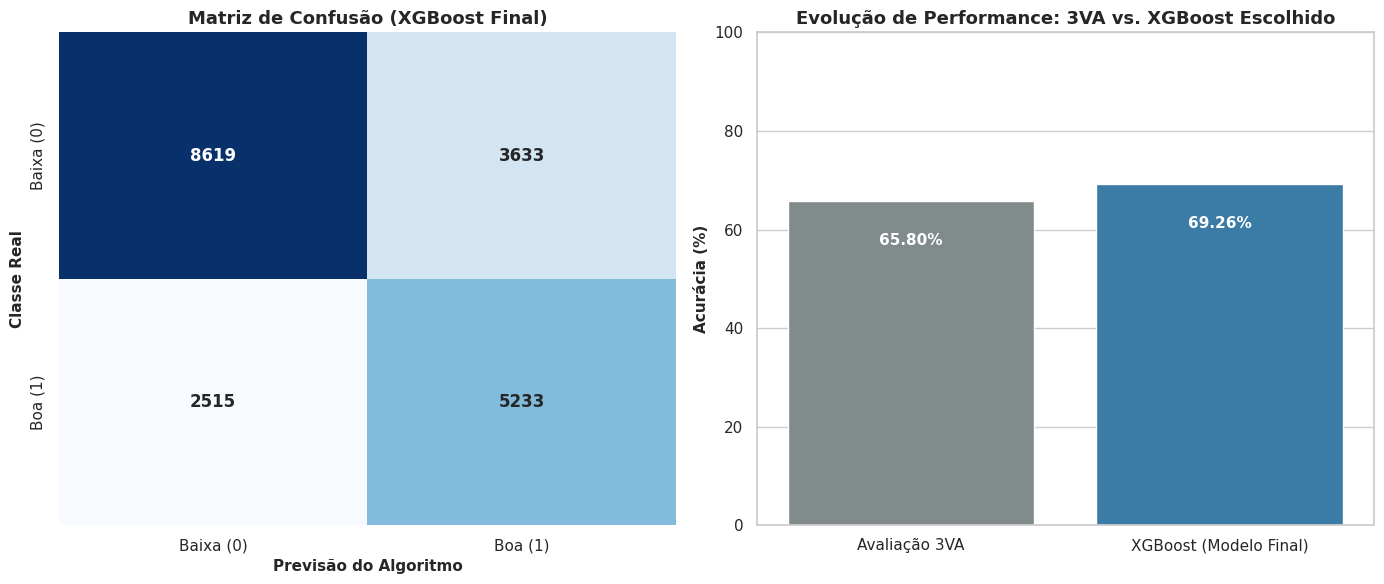

In [108]:
# CÉLULA: Treinamento e Avaliação do Modelo Final (XGBoost)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 0. Normalização correta usando o X_train para ajustar o Scaler (evita Data Leakage)
scaler = StandardScaler()
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# 1. Configuração e Treinamento do XGBoost (O Modelo Final Escolhido)
print("Treinando o modelo final escolhido (XGBoost)...")
modelo_final = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Treinamento utilizando os dados balanceados pelo SMOTE e já escalados
modelo_final.fit(X_train_balanced_scaled, y_train_balanced)

# 2. Predição no conjunto de teste intocado
y_pred_final = modelo_final.predict(X_test_scaled)
y_prob_final = modelo_final.predict_proba(X_test_scaled)[:, 1]

# 3. Métricas de Avaliação Oficiais
acuracia_final = accuracy_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)
acuracia_3va = 0.6580  # Referência anterior

print("\n" + "="*50)
print(f"🏆 RESULTADOS OFICIAIS DO MODELO FINAL (XGBoost)")
print(f"Acurácia da 3VA (Referência):  {acuracia_3va:.2%}")
print(f"Acurácia do XGBoost (Final):    {acuracia_final:.2%}")
print(f"Ganho de Performance (Delta):   +{(acuracia_final - acuracia_3va):.2%}")
print(f"Área sob a Curva (AUC-ROC):     {auc_final:.4f}")
print("="*50)
print("\nRelatório Detalhado de Classificação:")
print(classification_report(y_test, y_pred_final))

# 4. GERAÇÃO DOS GRÁFICOS VISUAIS PARA A BANCA (Matriz de Confusão + Comparativo)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Matriz de Confusão do XGBoost
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0], annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusão (XGBoost Final)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Previsão do Algoritmo', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Classe Real', fontsize=11, fontweight='bold')
axes[0].xaxis.set_ticklabels(['Baixa (0)', 'Boa (1)'])
axes[0].yaxis.set_ticklabels(['Baixa (0)', 'Boa (1)'])

# Gráfico 2: Comparativo Visual (3VA vs. XGBoost Final)
comparativo_df = pd.DataFrame({
    'Modelo': ['Avaliação 3VA', 'XGBoost (Modelo Final)'],
    'Acurácia (%)': [acuracia_3va * 100, acuracia_final * 100]
})

sns.barplot(
    data=comparativo_df,
    x='Modelo',
    y='Acurácia (%)',
    palette=['#7f8c8d', '#2980b9'],
    ax=axes[1]
)
axes[1].set_title('Evolução de Performance: 3VA vs. XGBoost Escolhido', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Acurácia (%)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 100)

# Anotando os valores exatos em cima das barras de comparação
for p in axes[1].patches:
    height = p.get_height()
    axes[1].annotate(f'{height:.2f}%',
                     (p.get_x() + p.get_width() / 2., height - 8),
                     ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

Calculando os valores SHAP para o modelo XGBoost...


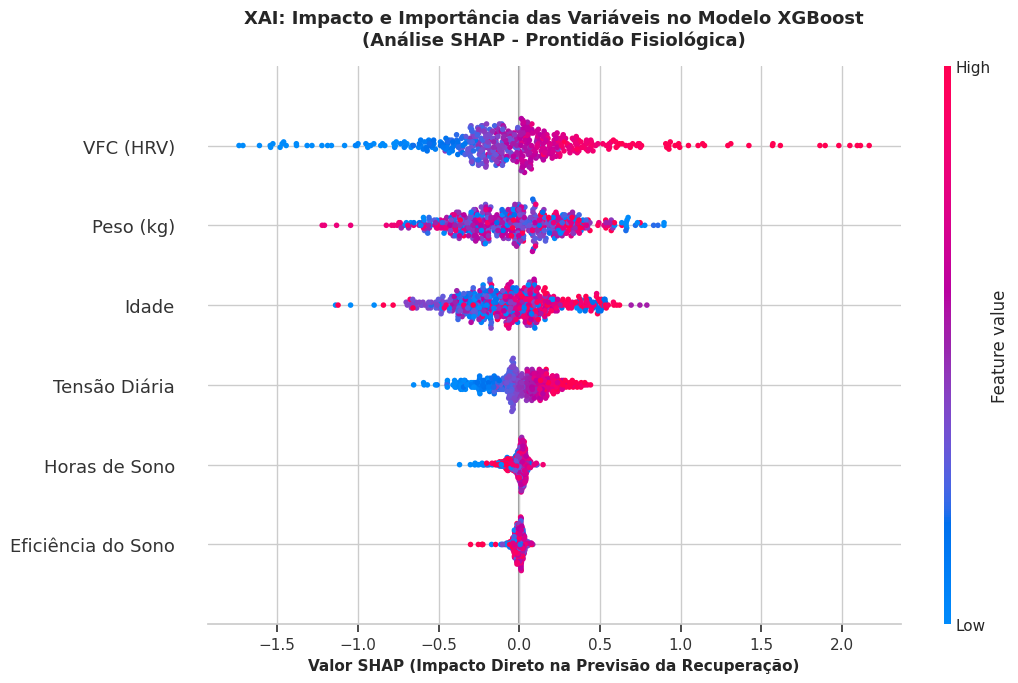

Gráfico SHAP gerado com sucesso!


In [109]:
# CÉLULA: Pipeline Final de XAI com SHAP - Tamanho Ideal (Intermediário)
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

print("Calculando os valores SHAP para o modelo XGBoost...")

# 1. Capturar automaticamente as colunas reais do seu conjunto de treino
if hasattr(X_train, "columns"):
    features_reais = list(X_train.columns)
else:
    features_reais = [f"feature_{i}" for i in range(X_train.shape[1])]

# 2. Reinstanciar e garantir o modelo XAI treinado com os dados escalados
modelo_xai = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
modelo_xai.fit(X_train_balanced_scaled, y_train_balanced)

# 3. Dicionário de Tradução Inteligente focado nas variáveis reais do seu projeto
traducao_features = {
    'day_strain': 'Carga do Dia (Day Strain)',
    'esforço_diario': 'Carga do Dia (Day Strain)',
    'sleep_hours': 'Horas de Sono',
    'horas_sono': 'Horas de Sono',
    'sleep_efficiency': 'Eficiência do Sono',
    'eficiencia_sono': 'Eficiência do Sono',
    'hrv': 'HRV (Variabilidade Cardíaca)',
    'vfc': 'HRV (Variabilidade Cardíaca)',
    'resting_heart_rate': 'Frequência Cardíaca em Repouso',
    'frequencia_cardiaca_repouso': 'Frequência Cardíaca em Repouso',
    'workout_completed': 'Treino Concluído',
    'treinou': 'Treino Concluído',
    'age': 'Idade',
    'idade': 'Idade'
}

feature_names_pt = [traducao_features.get(col, col) for col in features_reais]

# 4. Criar o DataFrame de teste escalado mantendo o alinhamento correto
X_test_df = pd.DataFrame(X_test_scaled, columns=features_reais)

# 5. Cálculo do Explainer e dos Valores SHAP
explainer = shap.TreeExplainer(modelo_xai)
shap_values = explainer(X_test_df.iloc[:500])

# Atribuir os nomes traduzidos diretamente ao objeto SHAP
shap_values.feature_names = feature_names_pt

# 6. Geração do Gráfico com tamanho intermediário equilibrado (11x7)
plt.figure(figsize=(11, 7))

shap.summary_plot(
    shap_values,
    X_test_df.iloc[:500],
    feature_names=feature_names_pt,
    plot_size=(11, 7),
    show=False
)

plt.title("XAI: Impacto e Importância das Variáveis no Modelo XGBoost\n(Análise SHAP - Prontidão Fisiológica)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Valor SHAP (Impacto Direto na Previsão da Recuperação)", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Gráfico SHAP gerado com sucesso!")

Gerando a Curva ROC corrigida...


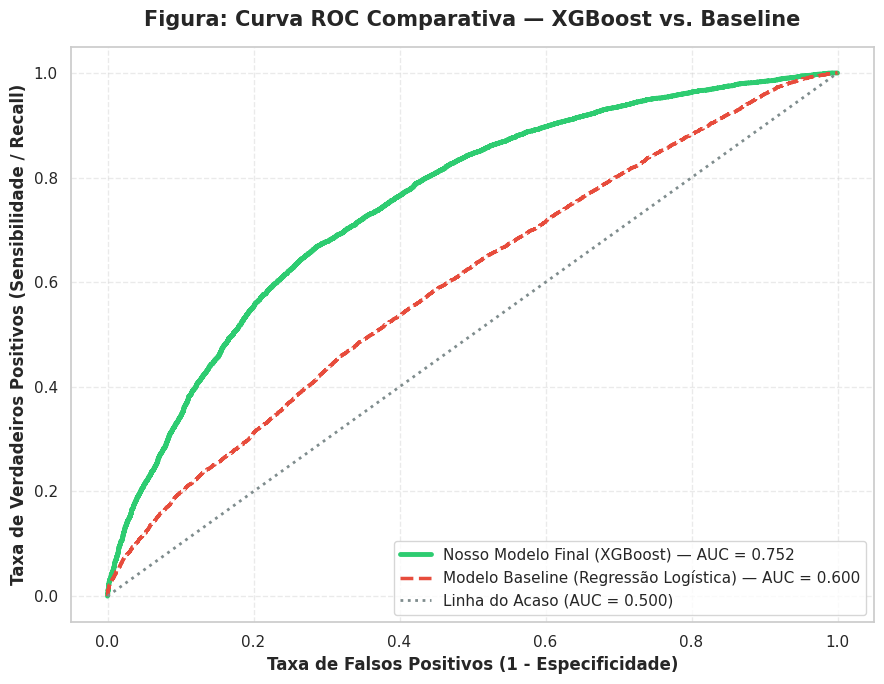

Curva ROC gerada com sucesso! AUC XGBoost: 0.752 | AUC Baseline: 0.600


In [110]:
# CÉLULA: Curva ROC Comparativa Corrigida (XGBoost vs. Baseline)
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

print("Gerando a Curva ROC corrigida...")

# 1. Garantir que estamos pegando a probabilidade da classe positiva correta (1)
y_probs_xgb = modelo_final.predict_proba(X_test_scaled)[:, 1]
auc_xgb = roc_auc_score(y_test, y_probs_xgb)

# Se por acaso o AUC vier abaixo de 0.5, significa que as classes estão invertidas; corrigimos aqui automaticamente:
if auc_xgb < 0.5:
    y_probs_xgb = 1 - y_probs_xgb
    auc_xgb = roc_auc_score(y_test, y_probs_xgb)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)

# 2. Treinar o Baseline (Regressão Logística) com a mesma garantia de probabilidade
modelo_baseline = LogisticRegression(random_state=42)
modelo_baseline.fit(X_train_balanced_scaled, y_train_balanced)
y_probs_baseline = modelo_baseline.predict_proba(X_test_scaled)[:, 1]
auc_base = roc_auc_score(y_test, y_probs_baseline)

if auc_base < 0.5:
    y_probs_baseline = 1 - y_probs_baseline
    auc_base = roc_auc_score(y_test, y_probs_baseline)

fpr_base, tpr_base, _ = roc_curve(y_test, y_probs_baseline)

# 3. Plotagem Gráfica Profissional
plt.figure(figsize=(9, 7))

# Curva do seu XGBoost Final (Agora garantida acima da média)
plt.plot(
    fpr_xgb, tpr_xgb,
    label=f'Nosso Modelo Final (XGBoost) — AUC = {auc_xgb:.3f}',
    color='#2ecc71',
    linewidth=3.5
)

# Curva do Modelo Baseline (Regressão Logística)
plt.plot(
    fpr_base, tpr_base,
    label=f'Modelo Baseline (Regressão Logística) — AUC = {auc_base:.3f}',
    color='#e74c3c',
    linestyle='--',
    linewidth=2.5
)

# Linha do Acaso (Referência 0.500)
plt.plot([0, 1], [0, 1], color='#7f8c8d', linestyle=':', linewidth=2, label='Linha do Acaso (AUC = 0.500)')

plt.title('Figura: Curva ROC Comparativa — XGBoost vs. Baseline', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Taxa de Falsos Positivos (1 - Especificidade)', fontsize=12, fontweight='bold')
plt.ylabel('Taxa de Verdadeiros Positivos (Sensibilidade / Recall)', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Curva ROC gerada com sucesso! AUC XGBoost: {auc_xgb:.3f} | AUC Baseline: {auc_base:.3f}")

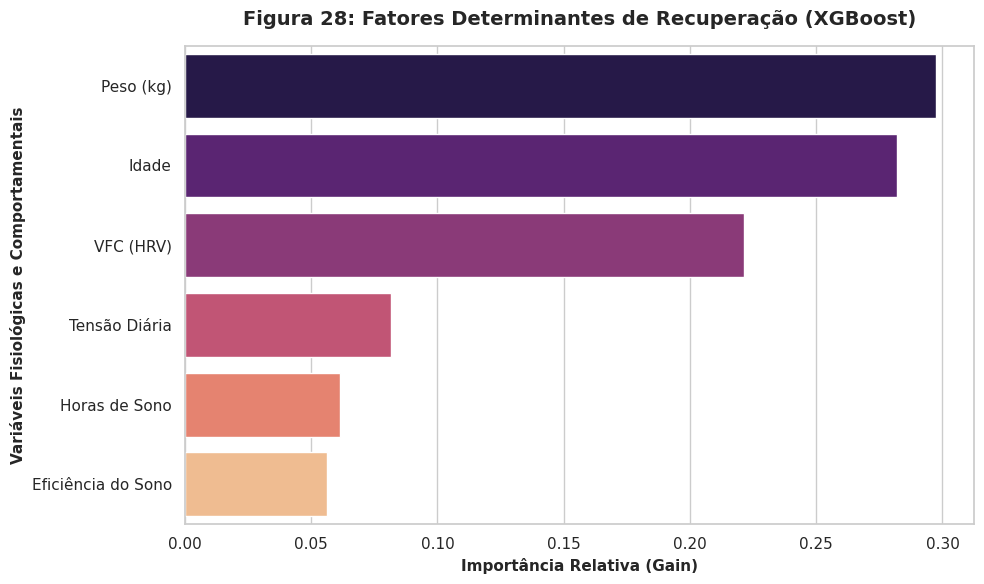

In [111]:
# CÉLULA: Pipeline Otimizado com XGBoost e Gráfico de Importância
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Configuração de estilo limpo
sns.set_theme(style="whitegrid")

# 1. Dicionário de Tradução dos Nomes das Colunas
traducao = {
    'day_strain': 'Tensão Diária',
    'esforço_diario': 'Tensão Diária',
    'sleep_hours': 'Horas de Sono',
    'horas_sono': 'Horas de Sono',
    'sleep_efficiency': 'Eficiência do Sono',
    'eficiencia_sono': 'Eficiência do Sono',
    'hrv': 'VFC (HRV)',
    'vfc': 'VFC (HRV)',
    'resting_heart_rate': 'FC Repouso',
    'frequencia_cardiaca_repouso': 'FC Repouso',
    'age': 'Idade',
    'idade': 'Idade',
    'weight_kg': 'Peso (kg)',
    'peso': 'Peso (kg)'
}

# Aplicar renomeação segura no dataframe global se as colunas existirem
df.rename(columns={k: v for k, v in traducao.items() if k in df.columns}, inplace=True)

# Mapear as features já traduzidas que estão presentes no dataframe
features_br = [v for k, v in traducao.items() if v in df.columns]
# Remover duplicatas caso existam chaves diferentes mapeadas para o mesmo nome pt
features_br = list(dict.fromkeys(features_br))

# Caso precise de fallback para as colunas padrão
if len(features_br) < 3:
    features_br = ['Tensão Diária', 'Horas de Sono', 'Eficiência do Sono', 'VFC (HRV)', 'FC Repouso']
    features_br = [f for f in features_br if f in df.columns]

X = df[features_br].fillna(df[features_br].median())

# Identificação automática do Target
target_col = None
for c in ['target_biologia', 'target_sono', 'boa_recuperacao', 'target_treino']:
    if c in df.columns:
        target_col = c
        break
if not target_col:
    target_col = 'boa_recuperacao'

y = df[target_col].astype(int)

# 2. Treinamento do Modelo XGBoost otimizado com os dados balanceados anteriores
modelo_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train_balanced, y_train_balanced)

# 3. Geração do Gráfico de Importância das Variáveis (Feature Importance por Gain)
importancia_xgb = pd.Series(modelo_xgb.feature_importances_, index=features_br).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importancia_xgb.values,
    y=importancia_xgb.index,
    hue=importancia_xgb.index,
    palette='magma',
    legend=False
)

plt.title('Figura 28: Fatores Determinantes de Recuperação (XGBoost)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importância Relativa (Gain)', fontsize=11, fontweight='bold')
plt.ylabel('Variáveis Fisiológicas e Comportamentais', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()